# Project 1 Jupyter Notebook: Shifting Social Roles

## Group 8: Gary Becker

Authors: Amanda Edwards, Ash Htet, Layla Jurow, Mattea Kalpakoff, Zitong Xu

In this Jupyter Notebook, we will be introducing population functions, population pyramids, and graphs in order to illustrate the impact of shifting social roles in the United States on population growth. We have incorporated data from the WBData Population  and  Federal Reserve Economic datasets.

## Imports

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import logging
import plotly.graph_objects as go
import sys
from pathlib import Path

# import wbdata...
try:
    import wbdata
    print("✅ wbdata is already installed! Skipping download.")

# If the computer says can't, THEN install it.
except ImportError:
    print("📦 wbdata not found. Installing it for you now...")
    !{sys.executable} -m pip install wbdata
    import wbdata
    print("✅ Done! wbdata is ready to use.")
logging.getLogger('shelved_cache').setLevel(logging.ERROR)
print("Libraries loaded.")

✅ wbdata is already installed! Skipping download.
Libraries loaded.


## Background

### Female Education and Labor Market Trends


As access to education for women has increased over time, women have entered the workforce at higher rates, reshaping labor market participation and economic outcomes. To demonstrate this shift our team analyzed the average years of schooling for women in the United States and graphed the relationship with female workplace participation rates.

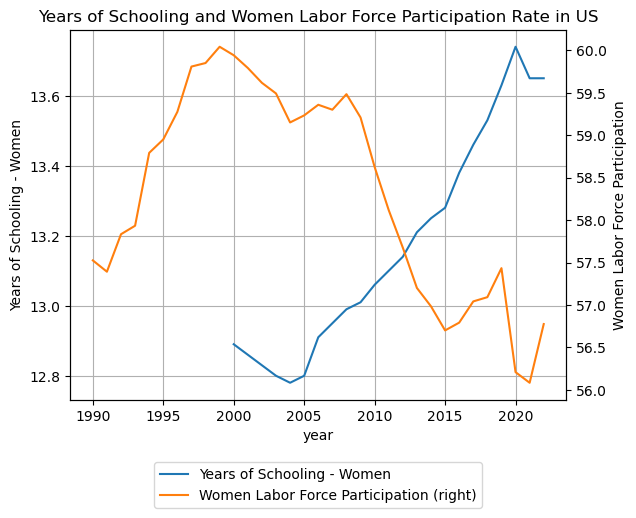

In [11]:
# Reads the csv file and saves it to the female_education variable
female_education = pd.read_csv("female_education.csv")
# Reformats the female_education table so that each year represents a row within a column "year"
us = female_education.loc[female_education["ISO_Code"] == "USA"].copy()
femal = female_education.loc[female_education["ISO_Code"] == "USA"].copy()
year_cols = [c for c in us.columns if str(c).isdigit()]
us_years = us[year_cols]
us_t = us_years.T
us_t = us_t.reset_index()
us_t.columns = ["year", "education"]   # rename the value column to whatever this dataset represents
us_t["year"] = us_t["year"].astype(int)
us_t.head()
female_education = us_t
# Reads the csv file and saves it to the female_employment variable
female_employment = pd.read_csv("female_employment.csv")
# Extracts the year from the year-month-day format in the csv
female_employment['year'] = pd.to_datetime(female_employment['observation_date']).dt.year
# Groups each year by the average employment rate over different dates
female_employment = female_employment.groupby('year')['LNS11300002'].mean()
female_employment = (
    female_employment
    .reset_index()
    .rename(columns={"LNS11300002": "employment_rate"})
)
# Combines female education and employment tables
edu_and_employ = pd.merge(
    female_education,
    female_employment,
    on=["year"]
)
# Cleans up the data so that it only includes years where there is data for both education and employment
clean = edu_and_employ.dropna(subset=["education", "employment_rate"])
clean.head()
# Generates the graph
ax = edu_and_employ.plot(
    x='year',
    y='education',
    label='Years of Schooling - Women'
)

edu_and_employ.plot(
    x='year',
    y='employment_rate',
    secondary_y=True,
    ax=ax,
    label='Women Labor Force Participation'
)

ax.set_ylabel('Years of Schooling - Women')
ax.right_ax.set_ylabel('Women Labor Force Participation')

ax.set_title('Years of Schooling and Women Labor Force Participation Rate in US')
ax.grid(True)

# Combine legends from both axes
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax.right_ax.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2)
ax.legend(lines_1 + lines_2, labels_1 + labels_2,loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.show()

The graph illustrates that although women’s education has increased steadily over time, women’s labor force participation peaked in the late 1990s and has declined since, which indicates that rising education does not necessarily translate into higher workforce participation after a certain point. This shift may also have something to do with the social roles of men and women in the household.

### Shifting Family Dynamics

Family dynamics in the United States have shifted alongside declining fertility and changing caregiving norms. Although Americans are having fewer children, parents—especially fathers—are spending more time on child care than previous generations. Time-use data show a substantial increase in fathers’ involvement in both child care and household labor, particularly since the COVID-19 pandemic, narrowing gender gaps in domestic work.

As fertility in the United States has declined and caregiving norms have changed, family dynamics have shifted. Despite Americans having fewer children, parents (particulary fathers) are spending more time on child care than previous generations. Time-use data shows a significant increase in fathers' involvement in both child care and household labor. 

These changes reflect the evolution of household social roles, as caregiving is shared rather than just a responsibiloity for women. As domestic responsibilities become more evenly distributed, women have more freedom to choose what roles they take on, influencing workforce trends. The following graph shows labor force participation rates over time for men, women, and the total population, providing context for how these social shifts align with changes in workforce behavior.

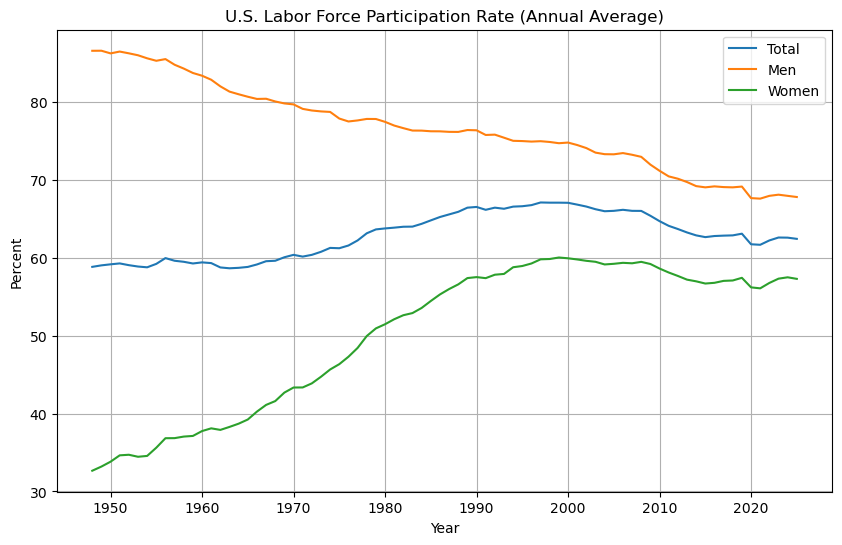

In [18]:
DATA_DIR = Path(".")  
FILES = {
    "Total": "CIVPART.csv",
    "Men": "LNS11300001.csv",
    "Women": "LNS11300002.csv",
}

total_raw = pd.read_csv(DATA_DIR / FILES["Total"])
men_raw   = pd.read_csv(DATA_DIR / FILES["Men"])
women_raw = pd.read_csv(DATA_DIR / FILES["Women"])
def standardize_lfpr(df: pd.DataFrame, series_name: str) -> pd.DataFrame:
   
    df = df.copy()

    if "observation_date" in df.columns:
        value_cols = [c for c in df.columns if c != "observation_date"]
        if len(value_cols) != 1:
            raise ValueError(
                f"{series_name}: expected 1 value column besides observation_date, found {value_cols}"
            )
        val_col = value_cols[0]
        out = df.rename(columns={"observation_date": "date", val_col: series_name})
        out["date"] = pd.to_datetime(out["date"])
        out[series_name] = pd.to_numeric(out[series_name], errors="coerce")
        return out[["date", series_name]].sort_values("date").reset_index(drop=True)

total = standardize_lfpr(total_raw, "Total")
men   = standardize_lfpr(men_raw, "Men")
women = standardize_lfpr(women_raw, "Women")
lfpr_monthly = total.merge(men, on="date", how="inner").merge(women, on="date", how="inner")
lfpr_annual = (
    lfpr_monthly.assign(year=lfpr_monthly["date"].dt.year)
    .groupby("year")[["Total", "Men", "Women"]]
    .mean()
    .reset_index()
    .sort_values("year")
    .reset_index(drop=True)
)
lfpr_monthly.to_csv(DATA_DIR / "lfpr_us_monthly_clean.csv", index=False)
lfpr_annual.to_csv(DATA_DIR / "lfpr_us_annual_clean.csv", index=False)

plt.figure(figsize=(10, 6))
plt.plot(lfpr_annual["year"], lfpr_annual["Total"], label="Total")
plt.plot(lfpr_annual["year"], lfpr_annual["Men"], label="Men")
plt.plot(lfpr_annual["year"], lfpr_annual["Women"], label="Women")
plt.title("U.S. Labor Force Participation Rate (Annual Average)")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.grid(True)
plt.legend()
plt.show()

In addition to creating this graph, our team also constructed unit tests to ensure our code worked, and defined a function that would make accessing the information in the graph much simpler. We will call this function later on in the project to understand what year data contains significant shifts in the labor force. The function will respond to queries of the following form:

"In [year] what was the labor force participation rate (%) for [Total/Men/Women]?"

In [24]:
assert not lfpr_monthly.empty, "Monthly LFPR dataset is empty after merge"
assert not lfpr_annual.empty, "Annual LFPR dataset is empty after aggregation"

assert lfpr_annual["year"].is_monotonic_increasing, "Years should be increasing"

assert lfpr_annual[["Total", "Men", "Women"]].notna().all().all(), "Missing values in annual LFPR"

bounds_ok = ((lfpr_annual[["Total", "Men", "Women"]] >= 0) &
             (lfpr_annual[["Total", "Men", "Women"]] <= 100)).all().all()
assert bounds_ok, "LFPR values out of bounds [0,100]"

assert lfpr_annual["Men"].mean() > lfpr_annual["Women"].mean(), "Unexpected: men's avg LFPR <= women's avg LFPR"

In [25]:
def lfpr_rate(year: int, sex: str, annual_df: pd.DataFrame = lfpr_annual) -> float:
    """
    Return labor force participation rate (%) for a given year and sex.
    sex must be one of: 'Total', 'Men', 'Women' (case-insensitive).
    """
    if not isinstance(year, int):
        raise TypeError("year must be an int")
    sex_norm = sex.strip().title()
    if sex_norm not in {"Total", "Men", "Women"}:
        raise ValueError("sex must be one of: 'Total', 'Men', 'Women'")

    row = annual_df.loc[annual_df["year"] == year, sex_norm]
    if row.empty:
        raise ValueError(f"Year {year} not found in dataset")
    return float(row.iloc[0])

Next,  begin to introduce the topic of population growth. In the following graphs, we assess how changing education and labor force rates have impacted fertility rates.  

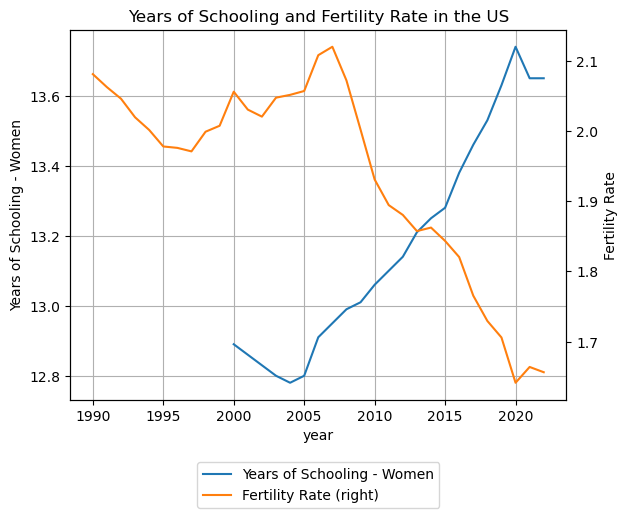

In [26]:
# Reads the csv file and saves it to the female_education variable
female_education = pd.read_csv("female_education.csv")
# Reformats the female_education table so that each year represents a row within a column "year"
us = female_education.loc[female_education["ISO_Code"] == "USA"].copy()
femal = female_education.loc[female_education["ISO_Code"] == "USA"].copy()
year_cols = [c for c in us.columns if str(c).isdigit()]
us_years = us[year_cols]
us_t = us_years.T
us_t = us_t.reset_index()
us_t.columns = ["year", "education"]   # rename the value column to whatever this dataset represents
us_t["year"] = us_t["year"].astype(int)
us_t.head()
female_education = us_t
# Reads the csv file and saves it to the fertility_rate variable
fertility_rate = pd.read_csv("fertility_rate.csv")
# Extracts the year from the year-month-day format in the csv
fertility_rate['year'] = pd.to_datetime(fertility_rate['observation_date']).dt.year
# Groups each year by the average employment rate over different dates
fertility_rate = fertility_rate.groupby('year')['SPDYNTFRTINUSA'].mean()
fertility_rate = (
    fertility_rate
    .reset_index()
    .rename(columns={"LNS11300002": "employment_rate"})
)
# Combines fertility rate and employment tables
edu_and_fertile = pd.merge(
    female_education,
    fertility_rate,
    on=["year"]
)
# Cleans up the data so that it only includes years where there is data for both education and employment
clean = edu_and_fertile.dropna(subset=["education", "SPDYNTFRTINUSA"])
clean.head()

# Generates the graph
ax = edu_and_fertile.plot(
    x='year',
    y='education',
    label='Years of Schooling - Women'
)

edu_and_fertile.plot(
    x='year',
    y='SPDYNTFRTINUSA',
    secondary_y=True,
    ax=ax,
    label='Fertility Rate'
)

ax.set_ylabel('Years of Schooling - Women')
ax.right_ax.set_ylabel('Fertility Rate')

ax.set_title('Years of Schooling and Fertility Rate in the US')
ax.grid(True)

# Combine legends from both axes
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax.right_ax.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2)
ax.legend(lines_1 + lines_2, labels_1 + labels_2,loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.show()

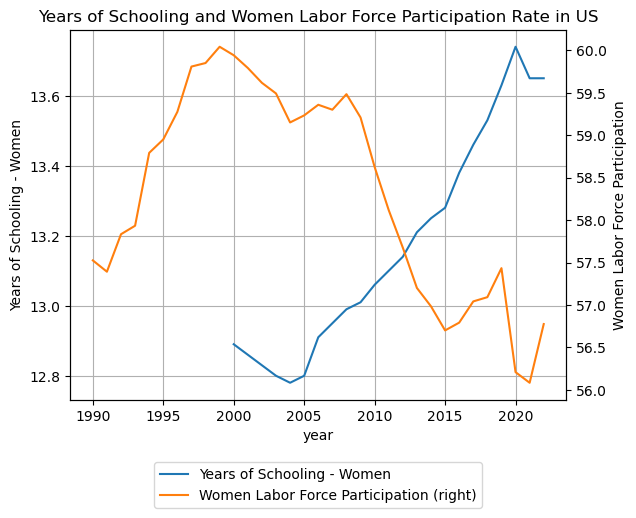

In [27]:
# Reads the csv file and saves it to the female_education variable
female_education = pd.read_csv("female_education.csv")
# Reformats the female_education table so that each year represents a row within a column "year"
us = female_education.loc[female_education["ISO_Code"] == "USA"].copy()
femal = female_education.loc[female_education["ISO_Code"] == "USA"].copy()
year_cols = [c for c in us.columns if str(c).isdigit()]
us_years = us[year_cols]
us_t = us_years.T
us_t = us_t.reset_index()
us_t.columns = ["year", "education"]   # rename the value column to whatever this dataset represents
us_t["year"] = us_t["year"].astype(int)
us_t.head()
female_education = us_t
# Reads the csv file and saves it to the female_employment variable
female_employment = pd.read_csv("female_employment.csv")
# Extracts the year from the year-month-day format in the csv
female_employment['year'] = pd.to_datetime(female_employment['observation_date']).dt.year
# Groups each year by the average employment rate over different dates
female_employment = female_employment.groupby('year')['LNS11300002'].mean()
female_employment = (
    female_employment
    .reset_index()
    .rename(columns={"LNS11300002": "employment_rate"})
)
# Combines female education and employment tables
edu_and_employ = pd.merge(
    female_education,
    female_employment,
    on=["year"]
)
# Cleans up the data so that it only includes years where there is data for both education and employment
clean = edu_and_employ.dropna(subset=["education", "employment_rate"])
clean.head()
# Generates the graph
ax = edu_and_employ.plot(
    x='year',
    y='education',
    label='Years of Schooling - Women'
)

edu_and_employ.plot(
    x='year',
    y='employment_rate',
    secondary_y=True,
    ax=ax,
    label='Women Labor Force Participation'
)

ax.set_ylabel('Years of Schooling - Women')
ax.right_ax.set_ylabel('Women Labor Force Participation')

ax.set_title('Years of Schooling and Women Labor Force Participation Rate in US')
ax.grid(True)

# Combine legends from both axes
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax.right_ax.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2)
ax.legend(lines_1 + lines_2, labels_1 + labels_2,loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.show()

# Population Function

To support our analysis we define a function that returns population dat for a given year, age range, sex, and country. The function will respond to queries of the following form: 

"In [year] how many [people/males/females] aged [low] to [high] were living in [the world/region/country]?"

In [1]:
def population(year=2020, sex="People", age_range=(0, 100), place="USA"):
    """
    Returns the population count for a given year, sex, age range, and place.
    Automatically handles 'People' by summing Male + Female to avoid missing data codes.
    """
    
    # Recursion for Total Population
    if sex == "People":
        males = population(year, "Male", age_range, place)
        females = population(year, "Female", age_range, place)
        return males + females

    # 1. Define World Bank Gender Suffixes
    if sex == "Male":
        suffix = ".MA"
    elif sex == "Female":
        suffix = ".FE"
    else:
        return 0 
        
    # 2. Map Age Ranges to World Bank Codes 
    ages = {
        0: "0004", 5: "0509", 10: "1014", 15: "1519", 20: "2024",
        25: "2529", 30: "3034", 35: "3539", 40: "4044", 45: "4549",
        50: "5054", 55: "5559", 60: "6064", 65: "6569", 70: "7074",
        75: "7579", 80: "80UP"
    }
    
    # 3. Build the Request
    variable_labels = {}
    low, high = age_range
    
    for start_age, code_mid in ages.items():
        # Include bucket if it overlaps with our range
        if start_age >= low and start_age < high:
            code = f"SP.POP.{code_mid}{suffix}"
            variable_labels[code] = "Count"
            
    if not variable_labels:
        return 0

    # 4. Fetch & Sum Data for specific country
    try:
        df = wbdata.get_dataframe(variable_labels, country=place)
    except:
        return 0 
        
    df.index = df.index.astype(int)
    
    # Return the sum for the requested year
    return int(df.loc[year].sum()) if year in df.index else 0